# Figure 1: Model Performance
kernal = utci

In [14]:
!pip install git+https://github.com/bikempastine/NeuralUTCI.git

  Cloning https://github.com/bikempastine/NeuralUTCI.git to c:\users\nerc-user\appdata\local\temp\pip-req-build-g0pcodb9
  Resolved https://github.com/bikempastine/NeuralUTCI.git to commit 63848b6a40f0370e579cfcd29785ffb8595b6505
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'


  Running command git clone --filter=blob:none --quiet https://github.com/bikempastine/NeuralUTCI.git 'C:\Users\nerc-user\AppData\Local\Temp\pip-req-build-g0pcodb9'
C:\Users\nerc-user\AppData\Roaming\Python\Python313\site-packages\IPython\utils\_process_win32.py:138: ResourceWarning: unclosed file <_io.BufferedWriter name=6>
  res = process_handler(cmd, _system_body)
C:\Users\nerc-user\AppData\Roaming\Python\Python313\site-packages\IPython\utils\_process_win32.py:138: ResourceWarning: unclosed file <_io.BufferedReader name=7>
  res = process_handler(cmd, _system_body)
C:\Users\nerc-user\AppData\Roaming\Python\Python313\site-packages\IPython\utils\_process_win32.py:138: ResourceWarning: unclosed file <_io.BufferedReader name=8>
  res = process_handler(cmd, _system_body)


In [15]:
# Standard library
import os
import glob
import math
import random
import calendar
from pathlib import Path
import zipfile

# Scientific stack
import numpy as np
import pandas as pd
import xarray as xr
from scipy import stats
from scipy.stats import gaussian_kde
from sklearn.metrics import mean_squared_error

# Machine learning / compute
import dask
import sklearn
import shap

# Visualization
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.cm as cm
from matplotlib.colors import BoundaryNorm, ListedColormap
from statsmodels.nonparametric.smoothers_lowess import lowess

# External models
from pythermalcomfort.models import utci as py_utci
from NeuralUTCI import utci as nn_utci

#uncatagorised
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from matplotlib.colors import to_rgb
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.cm as cm
from scipy.stats import gaussian_kde
from statsmodels.nonparametric.smoothers_lowess import lowess
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.cm as cm
from scipy.stats import gaussian_kde
from statsmodels.nonparametric.smoothers_lowess import lowess

## Load the data

In [16]:
esm4 = pd.read_csv('../data/ESM_4_Table_Offset.DAT', sep='\t', comment='*')
test = pd.read_csv('../data/UTCI-Test-Data.txt', sep='\t', comment='#')

## Run the NeuralUTCI and add to the datasets

In [17]:
# Test data
test['Tr'] = test['Tr-Ta'] + test['Ta']  # convert to absolute MRT
test["UTCI_NN"] = nn_utci(Ta=test['Ta'], Tr=test['Tr'], va=test['va'], rH=test['rH']) 

# Training data
esm4['Tr'] = esm4['Tr-Ta'] + esm4['Ta']  # convert to absolute MRT
esm4['UTCI_NN'] = nn_utci(Ta=esm4['Ta'], Tr=esm4['Tr'], va=esm4['va'], rH=esm4['rH'])


### Add the Polynomial estimates to the training dataset

In [18]:
esm4['UTCI_polynomial'] = py_utci(tdb = esm4['Ta'], tr = esm4['Tr'], v = esm4['va'], rh = esm4['rH'])['utci']
esm4['UTCI'] = esm4['Offset'] + esm4['Ta']
esm4["nn_error"] = esm4["UTCI_NN"] - esm4["UTCI"]
esm4["polynomial_error"] = esm4["UTCI_polynomial"] - esm4["UTCI"]

#### Save the results

In [19]:
test_analysis = test.copy()
test_analysis.to_csv("../results/utci_test_data_with_nn.csv", index=False)

In [20]:
test.head()

,Ta,Tr-Ta,va,rH,pa,Offset,UTCI,UTCI_Table,UTCI_polynomial,Tr,UTCI_NN
0,-49.9,-16.7,28,78,0.01,-60.97,-110.87,-109.15,-95.2,-66.6,-110.524582
1,-49.8,-14.6,14,77,0.01,-39.58,-89.38,-89.48,-90.4,-64.4,-89.975266
2,-49.2,-5.6,18,100,0.01,-46.63,-95.83,-96.02,-98.7,-54.8,-96.146790
3,-49.0,-17.2,5,98,0.01,-18.47,-67.47,-67.18,-66.1,-66.2,-67.439018
4,-48.9,-15.7,13,83,0.01,-37.69,-86.59,-86.47,-86.1,-64.6,-86.595291


## Symbolic regression

In [21]:
def sr_model(x0, x1, x2, x3):
    """
    x0 Ta
    x1 Tr
    x2 va
    x3 rh
    """
    return (x0 + ((x0 * (((np.log(x3) - (((x2 ** 0.73223144) - 24.531776) - (x0 * 0.23798576))) * x2) * 0.0017920851)) - (((np.log(x2) + 2.6093476) * np.log(x2)) + ((((x1 - x0) * (x2 ** -0.10247417)) * -0.29324478) + x2))))

In [22]:
test_analysis['SR_Model'] = sr_model(test_analysis['Ta'], test_analysis['Tr'], test_analysis['va'], test_analysis['rH'])

#### Model performance

In [23]:
def compute_metrics(df, mask, true_col, pred_col):
    y_true = df.loc[mask, true_col]
    y_pred = df.loc[mask, pred_col]
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    me = np.mean(y_true - y_pred)
    return rmse, me

conditions = {
    "Wind speed >17 m/s": test_analysis['va'] > 17,
    "Wind speed <17 m/s": test_analysis['va'] < 17,
    "Full range": test_analysis.index
}

models = {
    "Polynomial": "UTCI_polynomial",
    "Neural Network": "UTCI_NN",
    "SR Model": "SR_Model"
}

rows = []
for cond_name, mask in conditions.items():
    for model_name, col in models.items():
        rmse, me = compute_metrics(test_analysis, mask, 'UTCI', col)
        rows.append({
            "Condition": cond_name,
            "Model": model_name,
            "RMSE (°C)": rmse,
            "ME (°C)": me
        })

results_df = pd.DataFrame(rows)
results_df["Condition"] = pd.Categorical(
    results_df["Condition"],
    categories=["Wind speed >17 m/s", "Wind speed <17 m/s", "Full range"],
    ordered=True
)
print(results_df)

            Condition           Model  RMSE (°C)   ME (°C)
0  Wind speed >17 m/s      Polynomial   9.038476 -5.325316
1  Wind speed >17 m/s  Neural Network   0.887468 -0.303833
2  Wind speed >17 m/s        SR Model   5.490075  3.470542
3  Wind speed <17 m/s      Polynomial   1.143913  0.053667
4  Wind speed <17 m/s  Neural Network   0.268217  0.108455
5  Wind speed <17 m/s        SR Model   2.928040 -0.190567
6          Full range      Polynomial   2.776511 -0.348470
7          Full range  Neural Network   0.364685  0.079261
8          Full range        SR Model   3.220996  0.134267


### Bootstrapping for CI

In [24]:
# make empty numpy arrays
rmse_NN = np.empty(1000)
rmse_poly = np.empty(1000)

# sample 1,000 times with replacement and calculate RMSE for each sample
for i in range(1000):
    sample = test_analysis.sample(500, random_state=i, replace=True)
    rmse_NN[i] = np.sqrt(mean_squared_error(sample["UTCI"], sample["UTCI_NN"]))
    rmse_poly[i] = np.sqrt(mean_squared_error(sample["UTCI"], sample["UTCI_polynomial"]))

# calculate the percentage difference in RMSE between the two models for each sample
rmse_diff = rmse_poly - rmse_NN
rmse_diff_percentage = (rmse_poly - rmse_NN) / rmse_poly * 100

In [25]:
print("Mean RMSE for Polynomial: {:.2f} °C".format(rmse_poly.mean()))
print("Mean RMSE for Neural Network: {:.2f} °C".format(rmse_NN.mean()))

print("25th percentile of RMSE for Polynomial: {:.2f} °C".format(np.quantile(rmse_poly, 0.25)))
print("25th percentile of RMSE for Neural Network: {:.2f} °C".format(np.quantile(rmse_NN, 0.25)))

print("75th percentile of RMSE for Polynomial: {:.2f} °C".format(np.quantile(rmse_poly, 0.75)))
print("75th percentile of RMSE for Neural Network: {:.2f} °C".format(np.quantile(rmse_NN, 0.75)))


Mean RMSE for Polynomial: 2.76 °C
Mean RMSE for Neural Network: 0.36 °C
25th percentile of RMSE for Polynomial: 2.53 °C
25th percentile of RMSE for Neural Network: 0.35 °C
75th percentile of RMSE for Polynomial: 2.99 °C
75th percentile of RMSE for Neural Network: 0.38 °C


In [26]:
print("25th percentile of RMSE Difference: {:.2f}".format(np.quantile(rmse_diff, 0.25)))
print("Arithmetic Mean of RMSE Difference: {:.2f}".format(rmse_diff.mean()))
print("75th percentile of RMSE Difference: {:.2f}".format(np.quantile(rmse_diff, 0.75)))

25th percentile of RMSE Difference: 2.17
Arithmetic Mean of RMSE Difference: 2.40
75th percentile of RMSE Difference: 2.62


In [27]:
# calculate the 95% confidence interval for the percentage difference in RMSE using quantiles
print("25th percentile of RMSE Difference: {:.2f} %".format(np.quantile(rmse_diff_percentage, 0.25)))
print("Arithmetic Mean of RMSE Difference: {:.2f} %".format(rmse_diff_percentage.mean()))
print("75th percentile of RMSE Difference: {:.2f} %".format(np.quantile(rmse_diff_percentage, 0.75)))

25th percentile of RMSE Difference: 85.76 %
Arithmetic Mean of RMSE Difference: 86.66 %
75th percentile of RMSE Difference: 87.73 %


In [28]:
# calculate the 95% confidence interval for the percentage difference in RMSE using the t-distribution
from scipy import stats
mean = np.mean(rmse_diff_percentage)
ci = stats.t.interval(0.95, len(rmse_diff_percentage)-1, loc=mean, scale=stats.sem(rmse_diff_percentage))

print("95% Confidence Interval of RMSE Difference: ({:.2f}, {:.2f}) %".format(ci[0], ci[1]))

95% Confidence Interval of RMSE Difference: (86.56, 86.76) %


## High wind bootstapping

In [29]:
# make empty numpy arrays
rmse_NN_wind = np.empty(1000)
rmse_poly_wind = np.empty(1000)

# make test data only high wind speed
test_analysis_wind = test_analysis[test_analysis['va'] > 17]

# sample 1,000 times with replacement and calculate RMSE for each sample
for i in range(1000):
    sample = test_analysis_wind.sample(500, random_state=i, replace=True)
    rmse_NN_wind[i] = np.sqrt(mean_squared_error(sample["UTCI"], sample["UTCI_NN"]))
    rmse_poly_wind[i] = np.sqrt(mean_squared_error(sample["UTCI"], sample["UTCI_polynomial"]))

# calculate the percentage difference in RMSE between the two models for each sample
rmse_diff = rmse_poly_wind - rmse_NN_wind
rmse_diff_percentage = (rmse_poly_wind - rmse_NN_wind) / rmse_poly_wind * 100

In [30]:
print("Mean RMSE for Polynomial: {:.2f} °C".format(rmse_poly_wind.mean()))
print("25th percentile of RMSE for Polynomial: {:.2f} °C".format(np.quantile(rmse_poly_wind, 0.25)))
print("75th percentile of RMSE for Polynomial: {:.2f} °C".format(np.quantile(rmse_poly_wind, 0.75)))

print("Mean RMSE for Neural Network: {:.2f} °C".format(rmse_NN_wind.mean()))
print("25th percentile of RMSE for Neural Network: {:.2f} °C".format(np.quantile(rmse_NN_wind, 0.25)))
print("75th percentile of RMSE for Neural Network: {:.2f} °C".format(np.quantile(rmse_NN_wind, 0.75)))

Mean RMSE for Polynomial: 9.03 °C
25th percentile of RMSE for Polynomial: 8.82 °C
75th percentile of RMSE for Polynomial: 9.26 °C
Mean RMSE for Neural Network: 0.89 °C
25th percentile of RMSE for Neural Network: 0.86 °C
75th percentile of RMSE for Neural Network: 0.91 °C


In [31]:
max_nn_error = []
max_poly_error = []

for i in range(1000):
    sample = test_analysis_wind.sample(50, random_state=i, replace=True)
    max_nn_error.append(sample["nn_error"].max())
    max_poly_error.append(sample["polynomial_error"].max())


print("Mean max NN error: {:.2f} °C".format(np.array(max_nn_error).mean()))
print("25th percentile of max NN error: {:.2f} °C".format(np.quantile(max_nn_error, 0.25)))
print("75th percentile of max NN error: {:.2f} °C".format(np.quantile(max_nn_error, 0.75)))

print("Mean max Polynomial error: {:.2f} °C".format(np.array(max_poly_error).mean()))
print("25th percentile of max Polynomial error: {:.2f} °C".format(np.quantile(max_poly_error, 0.25)))
print("75th percentile of max Polynomial error: {:.2f} °C".format(np.quantile(max_poly_error, 0.75)))

KeyError: 'nn_error'

### Miscatagorisation bootstrapping

In [ ]:
def utci_category(utci):
    if utci > 46:
        return 'Extreme heat stress'
    elif utci > 38:
        return 'Very strong heat stress'
    elif utci > 32:
        return 'Strong heat stress'
    elif utci > 26:
        return 'Moderate heat stress'
    elif utci > 9:
        return 'No thermal stress'
    elif utci > 0:
        return 'Slight cold stress'
    elif utci > -13:
        return 'Moderate cold stress'
    elif utci > -27:
        return 'Strong cold stress'
    elif utci > -40:
        return 'Very strong cold stress'
    else:
        return 'Extreme cold stress'



In [ ]:
# compute categories for true, polynomial, and NN predictions
utci_cat = pd.DataFrame({
    "true_cat": test_analysis['UTCI'].apply(utci_category),
    "poly_cat": test_analysis['UTCI_polynomial'].apply(utci_category),
    "nn_cat": test_analysis['UTCI_NN'].apply(utci_category)
})



utci_cat["poly_mismatch"] = utci_cat["true_cat"] != utci_cat["poly_cat"]
utci_cat["nn_mismatch"] = utci_cat["true_cat"] != utci_cat["nn_cat"]


In [ ]:
# make empty numpy arrays
miscat_NN = np.empty(1000)
miscat_poly = np.empty(1000)
miscat_diff = np.empty(1000)

# sample 1,000 times with replacement and calculate mismatch rates for each sample
for i in range(1000):
    sample = utci_cat.sample(1000, random_state=i, replace=True)
    miscat_NN[i] = sample["nn_mismatch"].sum() / len(sample) * 100
    miscat_poly[i] = sample["poly_mismatch"].sum() / len(sample) * 100
    miscat_diff[i] = (miscat_poly[i] - miscat_NN[i]) / miscat_poly[i] * 100


In [ ]:
print("25th percentile of Mismatch Rate Difference NN: {:.2f}".format(np.quantile(miscat_NN, 0.25)))
print("Arithmetic Mean of Mismatch Rate Difference NN: {:.2f}".format(miscat_NN.mean()))
print("75th percentile of Mismatch Rate Difference NN: {:.2f}".format(np.quantile(miscat_NN, 0.75)))

25th percentile of Mismatch Rate Difference NN: 1.40
Arithmetic Mean of Mismatch Rate Difference NN: 1.71
75th percentile of Mismatch Rate Difference NN: 2.00


In [ ]:
print("25th percentile of Mismatch Rate Difference Poly: {:.2f}".format(np.quantile(miscat_poly, 0.25)))
print("Arithmetic Mean of Mismatch Rate Difference Poly: {:.2f}".format(miscat_poly.mean()))
print("75th percentile of Mismatch Rate Difference Poly: {:.2f}".format(np.quantile(miscat_poly, 0.75)))

25th percentile of Mismatch Rate Difference Poly: 4.80
Arithmetic Mean of Mismatch Rate Difference Poly: 5.26
75th percentile of Mismatch Rate Difference Poly: 5.70


In [ ]:
print("25th percentile of Mismatch Rate Difference Poly: {:.2f}".format(np.quantile(miscat_diff, 0.25)))
print("Arithmetic Mean of Mismatch Rate Difference Poly: {:.2f}".format(miscat_diff.mean()))
print("75th percentile of Mismatch Rate Difference Poly: {:.2f}".format(np.quantile(miscat_diff, 0.75)))

25th percentile of Mismatch Rate Difference Poly: 61.82
Arithmetic Mean of Mismatch Rate Difference Poly: 67.18
75th percentile of Mismatch Rate Difference Poly: 73.21


## Produce the figures

In [34]:
test_analysis["nn_error"] = test_analysis["UTCI_NN"] - test_analysis["UTCI"] 
test_analysis["polynomial_error"] = test_analysis["UTCI_polynomial"] - test_analysis["UTCI"] 

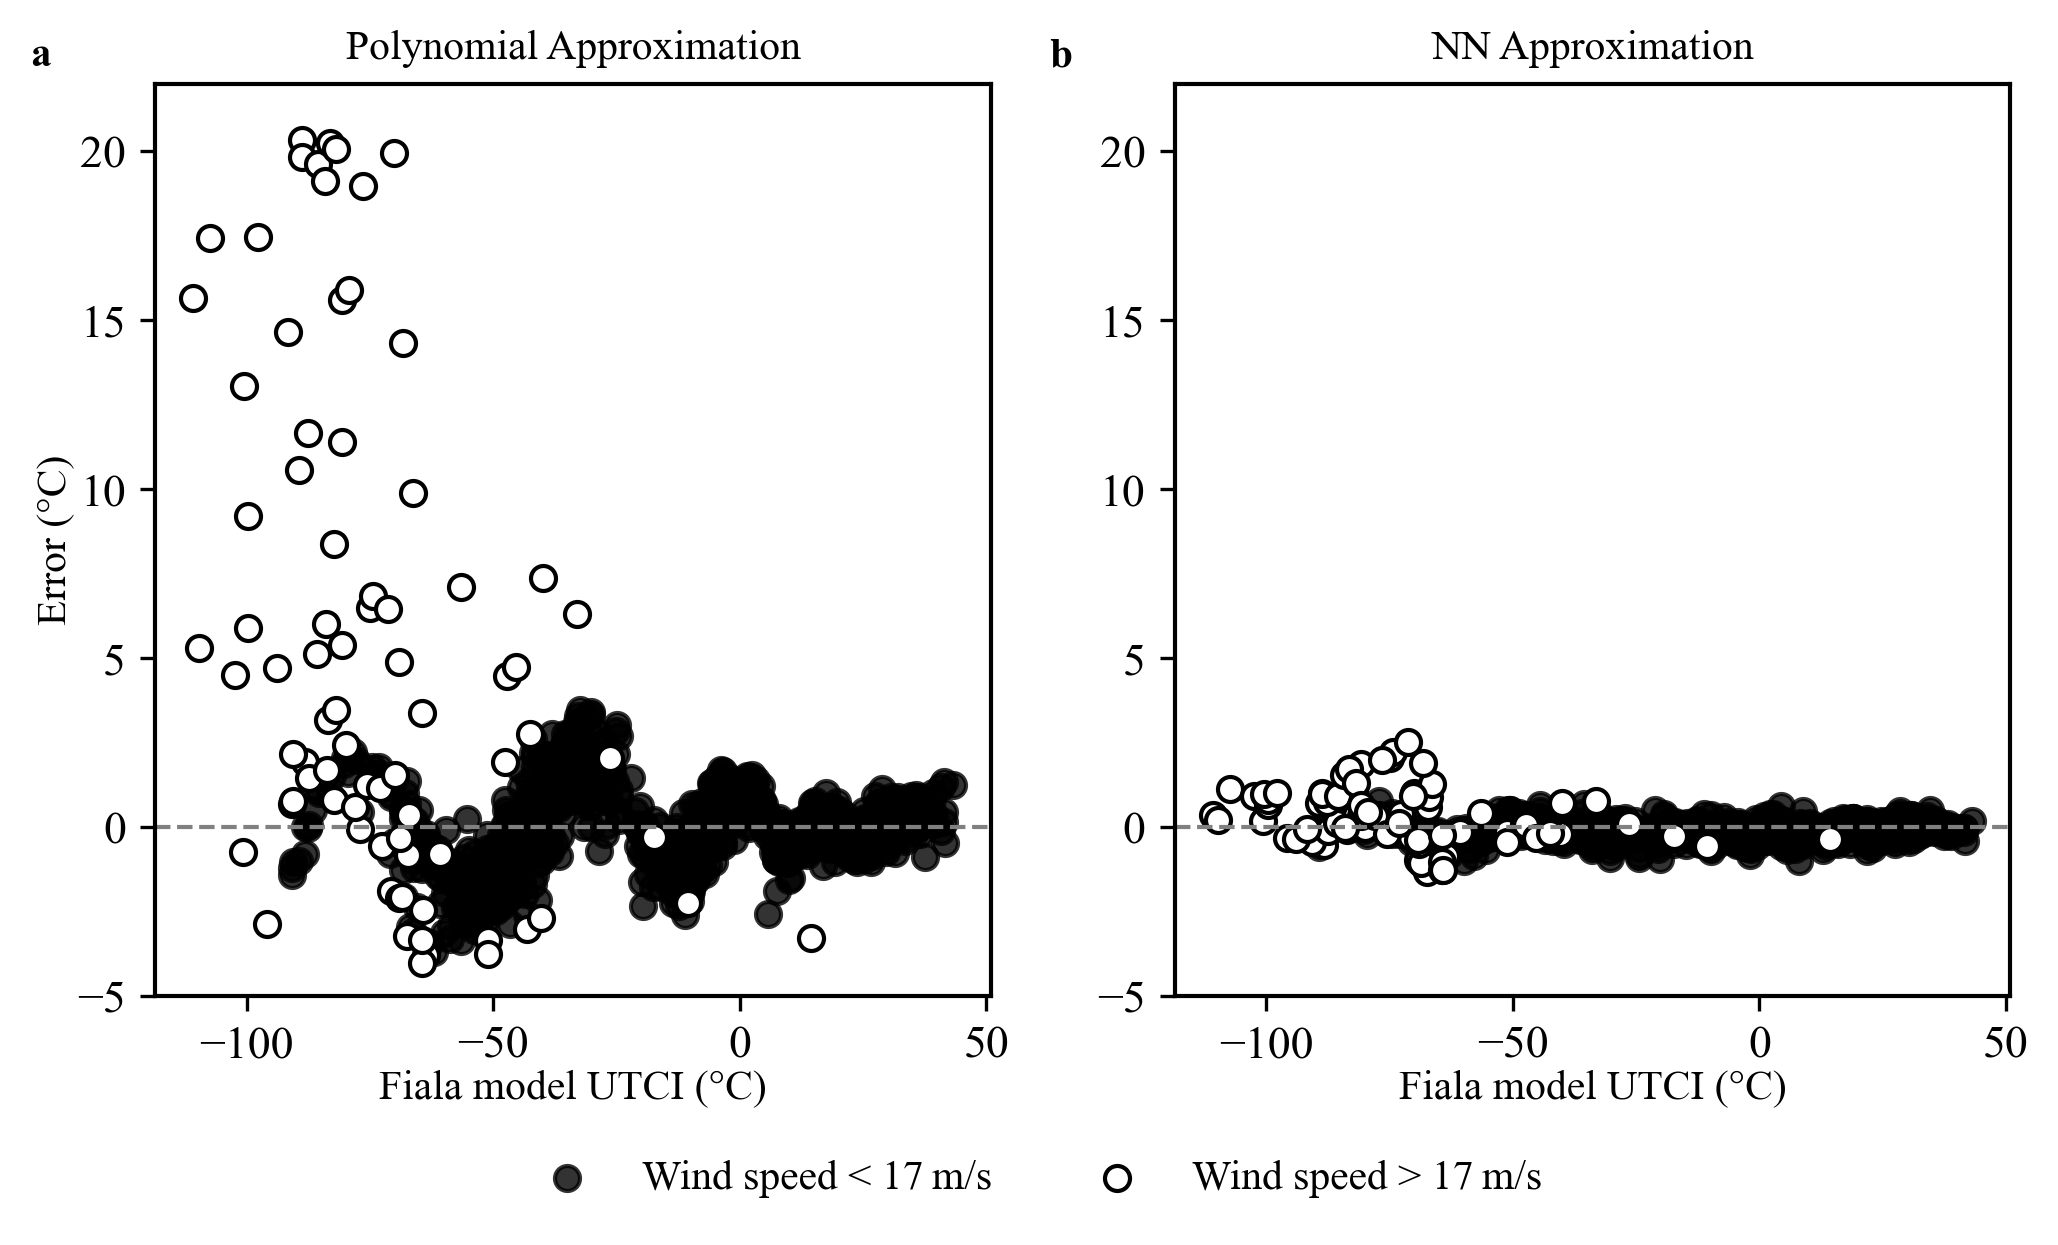

In [35]:
nan_mask = test_analysis['va'] > 17

fig, axs = plt.subplots(1, 2, figsize=(7, 4))

# Shared scatter settings
scatter_kwargs_in = dict(alpha=0.8, color='black', label='Wind speed < 17 m/s')
scatter_kwargs_out = dict(facecolors='white', edgecolors='black', alpha=1, label='Wind speed > 17 m/s')

# --- Plot Polynomial Error (Left) ---
axs[0].scatter(test_analysis.loc[~nan_mask, 'UTCI'], test_analysis.loc[~nan_mask, 'polynomial_error'], **scatter_kwargs_in)
axs[0].scatter(test_analysis.loc[nan_mask, 'UTCI'], test_analysis.loc[nan_mask, 'polynomial_error'], **scatter_kwargs_out)
axs[0].set_xlabel('Fiala model UTCI (°C)', fontsize=10)
axs[0].set_ylabel('Error (°C)', fontsize=10)
axs[0].set_title('Polynomial Approximation', fontsize=10)
axs[0].set_ylim(-5, 22)
axs[0].axhline(0, color='gray', linestyle='--', linewidth=1)
axs[0].grid(False)

# --- Plot NN Error (Right) ---
axs[1].scatter(test_analysis.loc[~nan_mask, 'UTCI'], test_analysis.loc[~nan_mask, 'nn_error'], **scatter_kwargs_in)
axs[1].scatter(test_analysis.loc[nan_mask, 'UTCI'], test_analysis.loc[nan_mask, 'nn_error'], **scatter_kwargs_out)
axs[1].set_xlabel('Fiala model UTCI (°C)', fontsize=10)
#axs[1].set_ylabel('NN Approximation', fontsize=10)
axs[1].set_title('NN Approximation', fontsize=10)
axs[1].set_ylim(-5, 22)
axs[1].axhline(0, color='gray', linestyle='--', linewidth=1)
axs[1].grid(False)

panel_labels = ['a', 'b']
for idx, ax in enumerate(axs.flat):
    ax.text(-0.15, 1.05, panel_labels[idx], transform=ax.transAxes,
            fontsize=10, fontweight='bold', va='top', ha='left')

# --- Single legend below plots ---
handles, labels = axs[1].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=2, fontsize=10, frameon=False, bbox_to_anchor=(0.5, -0.05))

plt.tight_layout()
plt.subplots_adjust(bottom=0.15)  # Space for legend

#plt.savefig("../results/main_text_figures/utci_error_comparison.png", dpi=300, bbox_inches='tight', transparent=False)
plt.show()

## Model improvement

## Figure 1. Model Performance

In [36]:
from matplotlib.lines import Line2D

#### Fig 1 with error attribution

In [37]:
def var_joint(std_A, std_B, rho):
    if rho == 0:
        var_A = std_A**2
        var_B = std_B**2
        var_A_B = var_A + var_B
        return var_A_B
    elif rho == 1:
        var_A = std_A**2
        var_B = std_B**2
        var_A_B = var_A + var_B + 2*np.sqrt(var_A * var_B)
        return var_A_B
    elif rho == -1:
        var_A = std_A**2
        var_B = std_B**2
        var_A_B = var_A + var_B - 2*np.sqrt(var_A * var_B)
        return var_A_B
    

# Parameters
std_A = 1.04
std_B_values = np.linspace(0, 3, 10)
rho_values = [0, 1, -1]


df = pd.DataFrame({
    "std_B": std_B_values,
    "rho_1": [var_joint(std_A, b, 1) for b in std_B_values],
    "rho_0": [var_joint(std_A, b, 0) for b in std_B_values],
    "rho_minus_1": [var_joint(std_A, b, -1) for b in std_B_values],

    "per_diff_rho_1": [(var_joint(std_A, b, 1) - 1.04)/1.04 *100 for b in std_B_values],
    "per_diff_rho_0": [(var_joint(std_A, b, 0) - 1.04)/1.04 *100 for b in std_B_values],
    "per_diff_rho_minus_1": [(var_joint(std_A, b, -1) - 1.04)/1.04 *100 for b in std_B_values],

    "per_diff_total_rho_1": [(var_joint(std_A, b, 1) - 1.04)/(var_joint(std_A, b, 1)) *100 for b in std_B_values],
    "per_diff_total_rho_0": [(var_joint(std_A, b, 0) - 1.04)/(var_joint(std_A, b, 0)) *100 for b in std_B_values],
    "per_diff_total_rho_minus_1": [(var_joint(std_A, b, -1) - 1.04)/(var_joint(std_A, b, -1)) *100 for b in std_B_values],

})

C:\Users\nerc-user\AppData\Local\Temp\ipykernel_13840\815128012.py:409: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.92, 1.0])  # leave room on right for colorbar


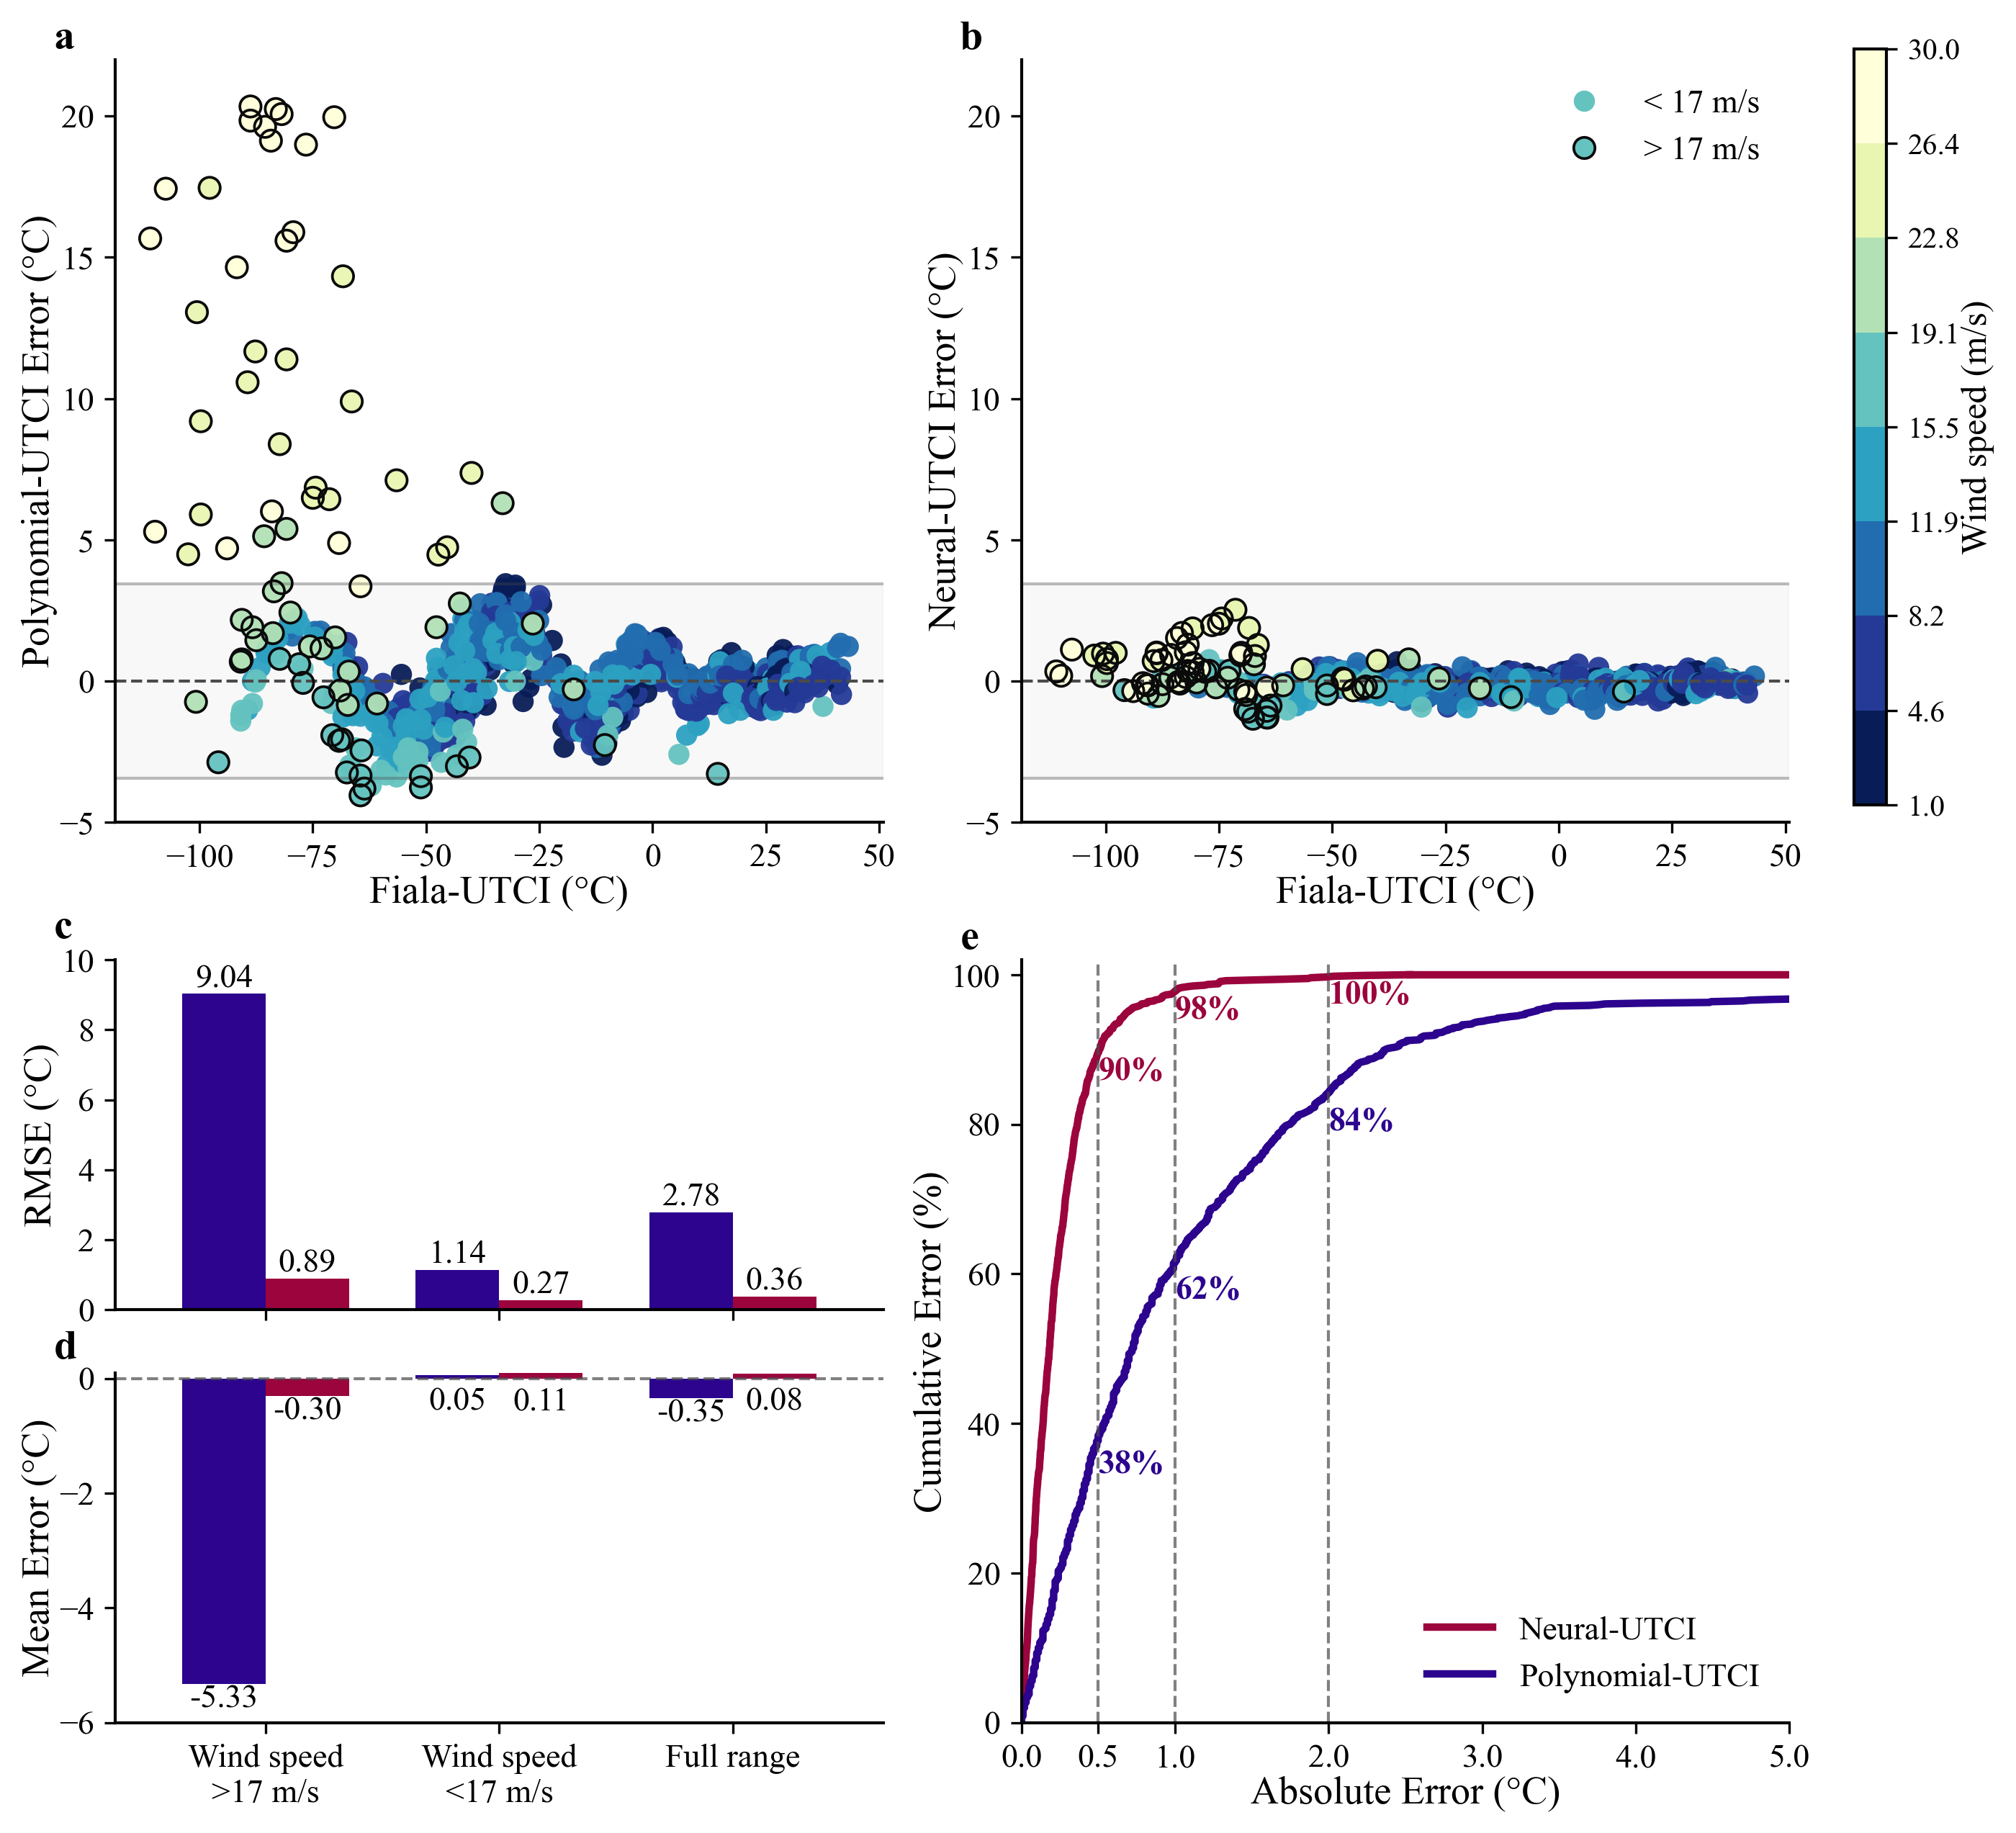

In [38]:
# ---------------------------
# rc settings
# ---------------------------
plt.rcParams.update({
    'figure.dpi': 300,                    # screen DPI (saving overrides with fig.savefig)
    'savefig.dpi': 600,                   # high-res saves
    'font.family': 'serif',
    'font.serif': ['Times New Roman', 'Times New Roman', 'Times New Roman'],
    'font.size': 12,                      # base font size (controls many defaults)
    'axes.titlesize': 13,
    'axes.labelsize': 12,
    'axes.labelpad': 0.5,
    'axes.linewidth': 1.0,
    'xtick.labelsize': 11,
    'ytick.labelsize': 11,
    'legend.fontsize': 11,
    'legend.frameon': False,
    'lines.linewidth': 1.5,
    'lines.markersize': 6,
    'axes.grid': False,
    'pdf.fonttype': 42,  # embed fonts as Truetype in PDF (better portability)
    'ps.fonttype': 42,
})



# Shared colors used in panel C and panel D
model_colors = {
    "Polynomial": "#2C048E",
    "Neural Network": "#9B043D"
}

# --- Create 2x2 subplot figure (arranged as in your design) ---
fig = plt.figure(figsize=(10, 10))  # reasonable manuscript size (inches)
gs = fig.add_gridspec(2, 2, hspace=0.18, wspace=0.18)

# Scatter plots occupy the two top panels
ax_poly = fig.add_subplot(gs[0, 0])  # Polynomial plot
ax_nn = fig.add_subplot(gs[0, 1])     # NN plot

# Panel c (bottom-left) contains the bar charts
subgs = gs[1, 0].subgridspec(2, 1, hspace=0.18)
ax_rmse = fig.add_subplot(subgs[0, 0])
ax_me = fig.add_subplot(subgs[1, 0])

# Cumulative error plot occupies bottom-right
ax_cum = fig.add_subplot(gs[1, 1])

# --- compute abs_error_diff once (kept from your original snippet) ---
test_analysis["abs_error_diff"] = test_analysis["polynomial_error"].abs() - test_analysis["nn_error"].abs()

# Colour bins for A and B
n_bins = 8
point_size = 50                 
outline_linewidth = 0.9
outline_color = '0.04'
va_outline_threshold = 17.0
band_alpha = 0.35
band_color = '#EDEDED'

# --- prepare bins, cmap and norm using the full va range (no filtering) ---
va_vals = test_analysis['va'].dropna()
bins = np.linspace(va_vals.min(), va_vals.max(), n_bins + 1)

# flipped colormap
cmap = plt.get_cmap('YlGnBu_r', n_bins)
norm = mcolors.BoundaryNorm(bins, ncolors=cmap.N, clip=True)

# tick labels
tick_positions = bins
tick_labels = [f"{b:.1f}" for b in bins]

# --- compute NN error band (global) ---
tolerance_band_max = test_analysis['polynomial_error'][test_analysis['va'] < 17].max()
tolerance_band_min = test_analysis['polynomial_error'][test_analysis['va'] < 17].min()
nn_range = tolerance_band_max - tolerance_band_min

# --- scatter kwargs used twice ---
scatter_kwargs = dict(
    c=test_analysis['va'],
    cmap=cmap,
    norm=norm,
    s=point_size,
    alpha=0.95,
    linewidths=0.4,
    edgecolors='none',
    marker='o',
    rasterized=True   # rasterize dense scatter when saving vector formats (keeps PDF size reasonable)
)

#################################################################
#### ========== POLYNOMIAL APPROXIMATION (TOP LEFT) ========== ####
#################################################################
sc0 = ax_poly.scatter(
    test_analysis['UTCI'],
    test_analysis['polynomial_error'],
    **scatter_kwargs
)
ax_poly.set_xlabel('Fiala-UTCI (°C)', fontsize=13)
ax_poly.set_ylabel('Polynomial-UTCI Error (°C)', fontsize=13)
ax_poly.set_ylim(-5, 22)
ax_poly.axhline(0, color='#4A4A4A', linestyle='--', linewidth=1)

# annotate NN band
ax_poly.axhspan(tolerance_band_min, tolerance_band_max, color=band_color, alpha=band_alpha, zorder=0)
ax_poly.axhline(tolerance_band_min, color='#4A4A4A', alpha=band_alpha, linestyle='-', linewidth=1)
ax_poly.axhline(tolerance_band_max, color='#4A4A4A', alpha=band_alpha, linestyle='-', linewidth=1)

#################################################################
#### ========== NN APPROXIMATION (TOP RIGHT) ========== ####
#################################################################
sc1 = ax_nn.scatter(
    test_analysis['UTCI'],
    test_analysis['nn_error'],
    **scatter_kwargs
)
ax_nn.set_xlabel('Fiala-UTCI (°C)', fontsize=13)
ax_nn.set_ylabel('Neural-UTCI Error (°C)', fontsize=13)
ax_nn.set_ylim(-5, 22)
ax_nn.axhline(0, color='#4A4A4A', linestyle='--', linewidth=1)

ax_nn.axhspan(tolerance_band_min, tolerance_band_max, color=band_color, alpha=band_alpha, zorder=0)
ax_nn.axhline(tolerance_band_min, color='#4A4A4A', alpha=band_alpha, linestyle='-', linewidth=1)
ax_nn.axhline(tolerance_band_max, color='#4A4A4A', alpha=band_alpha, linestyle='-', linewidth=1)

# --- Add outlines for points where va > threshold ---
high_va = test_analysis['va'] > va_outline_threshold
ax_poly.scatter(
    test_analysis.loc[high_va, 'UTCI'],
    test_analysis.loc[high_va, 'polynomial_error'],
    facecolors='none',
    edgecolors=outline_color,
    linewidths=outline_linewidth,
    s=point_size,
    zorder=3,
    rasterized=False
)
ax_nn.scatter(
    test_analysis.loc[high_va, 'UTCI'],
    test_analysis.loc[high_va, 'nn_error'],
    facecolors='none',
    edgecolors=outline_color,
    linewidths=outline_linewidth,
    s=point_size,
    zorder=3,
    rasterized=False
)

legend_elements = [
    Line2D(
        [0], [0],
        marker='o',
        linestyle='None',
        markersize=np.sqrt(point_size),
        markerfacecolor='#64C3BF',
        markeredgecolor='none',
        label='< 17 m/s'
    ),
    Line2D(
        [0], [0],
        marker='o',
        linestyle='None',
        markersize=np.sqrt(point_size),
        markerfacecolor='#64C3BF',
        markeredgecolor=outline_color,
        markeredgewidth=outline_linewidth,
        label='> 17 m/s'
    )
]

# Add legend in top corner
ax_nn.legend(
    handles=legend_elements,
    loc='upper right',
    frameon=False,
    fontsize=11
)

###################################################################################
##### ======== PANEL C: RMSE and Mean Error Bar Charts (shared x-axis) ======== ####
###################################################################################

order = ["Wind speed >17 m/s", "Wind speed <17 m/s", "Full range"]

display_labels = [
    "Wind speed\n>17 m/s",
    "Wind speed\n<17 m/s",
    "Full range"
]

models = ["Polynomial", "Neural Network"]
spacing = 0.7
x = np.arange(len(order)) * spacing
bar_width = 0.25

# Pull values in the desired order
rmse_pivot = (
    results_df.pivot(index="Condition", columns="Model", values="RMSE (°C)")
    .reindex(order)
)
me_pivot = (
    results_df.pivot(index="Condition", columns="Model", values="ME (°C)")
    .reindex(order)
)

# --- RMSE (top) ---
ax_rmse.bar(
    x - bar_width / 2,
    rmse_pivot["Polynomial"].values,
    width=bar_width,
    color=model_colors["Polynomial"],
    label="Polynomial-UTCI"
)
ax_rmse.bar(
    x + bar_width / 2,
    rmse_pivot["Neural Network"].values,
    width=bar_width,
    color=model_colors["Neural Network"],
    label="Neural-UTCI"
)

ax_rmse.set_ylim(0, 10)
ax_rmse.set_title("")
ax_rmse.set_xlabel("")
ax_rmse.set_ylabel("RMSE (°C)", fontsize=13)

# force matching x ticks on both axes
ax_rmse.set_xticks(x)
ax_rmse.set_xticklabels([])
ax_rmse.tick_params(axis="x", labelbottom=False)

margin = 0.45
ax_rmse.set_xlim(x[0] - margin, x[-1] + margin)
ax_me.set_xlim(x[0] - margin, x[-1] + margin)

# remove legend if present
leg = ax_rmse.get_legend()
if leg is not None:
    leg.remove()

# --- ME (bottom) ---
ax_me.bar(
    x - bar_width / 2,
    me_pivot["Polynomial"].values,
    width=bar_width,
    color=model_colors["Polynomial"],
    label="Polynomial"
)
ax_me.bar(
    x + bar_width / 2,
    me_pivot["Neural Network"].values,
    width=bar_width,
    color=model_colors["Neural Network"],
    label="Neural Network"
)

ax_me.set_ylim(-6, 0.1)
ax_me.set_title("")
ax_me.set_xlabel("")
ax_me.set_ylabel("Mean Error (°C)", fontsize=13)
ax_me.axhline(0, color="#4A4A4A", linestyle="--", linewidth=1, alpha=0.7)

# force matching x ticks on both axes
ax_me.set_xticks(x)
ax_me.set_xticklabels(display_labels, rotation=0, ha="center")

# remove legend if present
leg = ax_me.get_legend()
if leg is not None:
    leg.remove()

# Labels
def add_bar_labels(ax, fmt="{:.2f}", mode="standard"):
    for container in ax.containers:
        for bar in container:
            height = bar.get_height()
            x_center = bar.get_x() + bar.get_width() / 2

            if mode == "standard":
                # default: above positive, below negative
                y = height
                va = 'bottom' if height >= 0 else 'top'

            elif mode == "positive_near_zero":
                if height > 0:
                    # positive → near zero (below it)
                    y = -0.15
                    va = 'top'
                else:
                    # negative → below the bar
                    y = height
                    va = 'top'

            ax.text(
                x_center, y,
                fmt.format(height),
                ha='center',
                va=va,
                fontsize=11
            )

# RMSE labels
add_bar_labels(ax_rmse, mode="standard")

# ME labels
add_bar_labels(ax_me, mode="positive_near_zero")

#################################################################
#### ======== CUMULATIVE ERROR DISTRIBUTION (BOTTOM RIGHT) ====== ####
#################################################################
def plot_cumulative_error(ax, errors, label, color, extend_to=5):
    abs_errors = np.abs(errors)
    sorted_errors = np.sort(abs_errors)
    cumulative = np.arange(1, len(sorted_errors) + 1) / len(sorted_errors) * 100

    # Plot the cumulative distribution
    ax.plot(sorted_errors, cumulative, label=label, color=color, linewidth=2.5)

    # Extend the line horizontally at 100% to the specified x-value
    if sorted_errors.size and sorted_errors[-1] < extend_to:
        ax.plot([sorted_errors[-1], extend_to], [100, 100],
                color=color, linewidth=2.5, linestyle='-')

    return abs_errors

# Plot NN and Polynomial error distributions using shared colors
nn_abs_errors = plot_cumulative_error(
    ax_cum, test_analysis["nn_error"],
    "Neural-UTCI", model_colors["Neural Network"], extend_to=10
)
poly_abs_errors = plot_cumulative_error(
    ax_cum, test_analysis["polynomial_error"],
    "Polynomial-UTCI", model_colors["Polynomial"], extend_to=10
)

# Reference lines
ax_cum.axvline(0.5, color='#4A4A4A', linestyle='--', linewidth=1, alpha=0.7)
ax_cum.axvline(1.0, color='#4A4A4A', linestyle='--', linewidth=1, alpha=0.7)
ax_cum.axvline(2.0, color='#4A4A4A', linestyle='--', linewidth=1, alpha=0.7)

# Labels and formatting
ax_cum.set_xlabel('Absolute Error (°C)', fontsize=13)
ax_cum.set_ylabel('Cumulative Error (%)', fontsize=13)
ax_cum.grid(False)
ax_cum.set_xlim(0, 5)
ax_cum.set_ylim(0, 102)
ax_cum.set_xticks([0, 0.5, 1, 2, 3, 4, 5])

# Annotate percentage within thresholds
for errors, color, y_offset in [
    (nn_abs_errors, model_colors["Neural Network"], -4.5),
    (poly_abs_errors, model_colors["Polynomial"], -6)
]:
    within_0_5 = np.mean(errors <= 0.5) * 100
    within_1_0 = np.mean(errors <= 1.0) * 100
    within_2_0 = np.mean(errors <= 2.0) * 100

    ax_cum.text(0.5, within_0_5 + y_offset, f'{within_0_5:.0f}%',
                verticalalignment='bottom', fontsize=11, color=color, fontweight='bold')
    ax_cum.text(1.0, within_1_0 + y_offset, f'{within_1_0:.0f}%',
                verticalalignment='bottom', fontsize=11, color=color, fontweight='bold')
    ax_cum.text(2.0, within_2_0 + y_offset, f'{within_2_0:.0f}%',
                verticalalignment='bottom', fontsize=11, color=color, fontweight='bold')

# Legend
ax_cum.legend(fontsize=11, loc='lower right', frameon=False)


# ========== PANEL LABELS ==========
panel_axes = [ax_poly, ax_nn, ax_cum]
panel_labels = ['a', 'b', 'e']

for ax, label in zip(panel_axes, panel_labels):
    ax.text(-0.08, 1.05, label,
            transform=ax.transAxes,
            fontsize=14,
            fontweight='bold',
            va='top',
            ha='left')

ax_rmse.text(-0.08, 1.14, 'c', transform=ax_rmse.transAxes, fontsize=14,
            fontweight='bold',
            va='top',
            ha='left')

ax_me.text(-0.08, 1.12, 'd', transform=ax_me.transAxes, fontsize=14,
               fontweight='bold',
               va='top',
               ha='left')


# ================ Splines ==========
# clean spines
for ax in [ax_poly, ax_nn, ax_rmse, ax_me, ax_cum]:
    for spine in ["top", "right"]:
        ax.spines[spine].set_visible(False)


# ========== COLOURBAR (RIGHT SIDE) ==========
sm = cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array(va_vals)
cax = fig.add_axes([0.93, 0.535, 0.015, 0.35])  # Positioned next to scatter plots
cbar = plt.colorbar(sm, cax=cax, boundaries=bins, ticks=tick_positions, spacing='proportional')
cbar.set_label('Wind speed (m/s)', fontsize=12)
cbar.ax.tick_params(labelsize=10)
cbar.ax.set_yticklabels(tick_labels)

# Tidy layout for manuscript
plt.tight_layout(rect=[0, 0, 0.92, 1.0])  # leave room on right for colorbar

# Save figure for manuscript
fig.savefig("main_text/final/figure1_with_bars.png", dpi=600, bbox_inches="tight", pad_inches=0.01)

plt.show()

### Neural-UTCI Improvement

In [208]:
test_analysis["abs_error_diff"] = test_analysis["polynomial_error"].abs() - test_analysis["nn_error"].abs()

In [209]:
print(f"NN improves: {test_analysis['abs_error_diff'][test_analysis['abs_error_diff']>0].count()/1000}")
print(f"Poly better: {test_analysis['abs_error_diff'][test_analysis['abs_error_diff']<0].count()/1000}")
print(f"NN improves over 1 degree: {test_analysis['abs_error_diff'][test_analysis['abs_error_diff']>1].count()/1000}")
print(f"Poly improves over 1 degree: {test_analysis['abs_error_diff'][test_analysis['abs_error_diff']<-1].count()}")
print(f"Poly improves over 0.5 degree: {test_analysis['abs_error_diff'][test_analysis['abs_error_diff']<-0.5].count()}")

NN improves: 0.85
Poly better: 0.15
NN improves over 1 degree: 0.324
Poly improves over 1 degree: 0
Poly improves over 0.5 degree: 7


In [210]:
import pandas as pd
import numpy as np

def utci_category(utci):
    if utci > 46:
        return 'Extreme heat stress'
    elif utci > 38:
        return 'Very strong heat stress'
    elif utci > 32:
        return 'Strong heat stress'
    elif utci > 26:
        return 'Moderate heat stress'
    elif utci > 9:
        return 'No thermal stress'
    elif utci > 0:
        return 'Slight cold stress'
    elif utci > -13:
        return 'Moderate cold stress'
    elif utci > -27:
        return 'Strong cold stress'
    elif utci > -40:
        return 'Very strong cold stress'
    else:
        return 'Extreme cold stress'

# Apply to your dataframe
test_analysis['utci_category'] = test_analysis['UTCI'].apply(utci_category)
esm4['utci_category'] = esm4['UTCI'].apply(utci_category)


## Calculate RMSE by category

In [211]:


rows = []

for category in test_analysis['utci_category'].unique():
    mask = test_analysis['utci_category'] == category

    y_true = test_analysis.loc[mask, 'UTCI']
    y_nn   = test_analysis.loc[mask, 'UTCI_NN']
    y_poly = test_analysis.loc[mask, 'UTCI_polynomial']

    rmse_nn   = np.sqrt(mean_squared_error(y_true, y_nn))
    rmse_poly = np.sqrt(mean_squared_error(y_true, y_poly))

    pct_decrease = (rmse_poly - rmse_nn) / rmse_poly * 100

    rows.append({
        'Category': category,
        'RMSE_NeuralUTCI': rmse_nn,
        'RMSE_Polynomial': rmse_poly,
        '% Decrease (NN vs Poly)': pct_decrease
    })

results_df = pd.DataFrame(rows)

print(results_df)

                  Category  RMSE_NeuralUTCI  RMSE_Polynomial  \
0      Extreme cold stress         0.524576         4.848768   
1  Very strong cold stress         0.318172         2.027307   
2       Strong cold stress         0.338438         1.313284   
3     Moderate cold stress         0.306638         1.126547   
4       Slight cold stress         0.344090         0.839321   
5        No thermal stress         0.226187         0.536732   
6     Moderate heat stress         0.200248         0.442682   
7       Strong heat stress         0.160114         0.552505   
8  Very strong heat stress         0.169324         0.696663   

   % Decrease (NN vs Poly)  
0                89.181250  
1                84.305700  
2                74.229643  
3                72.780695  
4                59.003744  
5                57.858481  
6                54.764751  
7                71.020424  
8                75.694950  


In [212]:
utci_cat = test_analysis['UTCI'].apply(utci_category)
utci_poly_cat =test_analysis['UTCI_polynomial'].apply(utci_category)
utci_nn_cat =test_analysis['UTCI_NN'].apply(utci_category)


In [213]:
## TRAINING DATA
utci_cat = esm4['UTCI'].apply(utci_category)
utci_poly_cat =esm4['UTCI_polynomial'].apply(utci_category)
utci_nn_cat =esm4['UTCI_NN'].apply(utci_category)

In [214]:
print("poly != UTCI cat:", {utci_cat[utci_cat != utci_poly_cat].count()/1000})
print("nn != UTCI cat:", {utci_cat[utci_cat != utci_nn_cat].count()/1000})

utci_cat[utci_cat != utci_nn_cat].count()/1000

poly != UTCI cat: {np.float64(17.353)}
nn != UTCI cat: {np.float64(1.293)}


np.float64(1.293)

In [215]:
 # Combine into one DataFrame for easy comparison
df = pd.DataFrame({
    "true_cat": utci_cat,
    "poly_cat": utci_poly_cat,
    "nn_cat": utci_nn_cat
})

# ---------------------------------------------------------
# 1. Boolean indicators for mismatch
# ---------------------------------------------------------
df["poly_mismatch"] = df["true_cat"] != df["poly_cat"]
df["nn_mismatch"] = df["true_cat"] != df["nn_cat"]


print("\n=== Mismatch counts per method ===")
print("NN:", df["nn_mismatch"].sum())
print("Polynomial:", df["poly_mismatch"].sum())
# ---------------------------------------------------------
# 2. Count mismatches by true UTCI category
# ---------------------------------------------------------
mismatch_by_category = pd.DataFrame({
    "poly_mismatch_count": df[df["poly_mismatch"]].groupby("true_cat").size(),
    "nn_mismatch_count": df[df["nn_mismatch"]].groupby("true_cat").size()
}).fillna(0).astype(int)

print("\n=== Mismatch counts per UTCI category ===")
print(mismatch_by_category)

# ---------------------------------------------------------
# 3. Check WHERE mismatches occur (same rows?)
# ---------------------------------------------------------
same_mismatch_locations = (df["poly_mismatch"] & df["nn_mismatch"])
same_mismatch_count = same_mismatch_locations.sum()
total_rows = len(df)

print("\n=== Agreement on mismatch locations ===")
print(f"Rows where both methods mismatch the same way: {same_mismatch_count}/{total_rows}")
print(f"Percentage of NN mismatches: {100 * same_mismatch_count/df["nn_mismatch"].sum():.2f}%")

# Rows where mismatches occur in both methods
matching_mismatch_rows = df[df["poly_mismatch"] & df["nn_mismatch"]]

print("\n=== Rows where BOTH methods mismatch (same location) ===")
print(matching_mismatch_rows)


=== Mismatch counts per method ===
NN: 1293
Polynomial: 17353

=== Mismatch counts per UTCI category ===
                         poly_mismatch_count  nn_mismatch_count
true_cat                                                       
Extreme cold stress                      170                  3
Extreme heat stress                     3338                 91
Moderate cold stress                    2927                223
Moderate heat stress                    1636                202
No thermal stress                       2380                105
Slight cold stress                       969                 98
Strong cold stress                      1105                 95
Strong heat stress                      1183                 71
Very strong cold stress                 2503                234
Very strong heat stress                 1142                171

=== Agreement on mismatch locations ===
Rows where both methods mismatch the same way: 777/104643
Percentage of NN mismatches

In [216]:
test_analysis['utci_cat'] = test_analysis['UTCI'].apply(utci_category)
test_analysis['utci_poly_cat'] = test_analysis['UTCI_polynomial'].apply(utci_category)
test_analysis['utci_nn_cat'] = test_analysis['UTCI_NN'].apply(utci_category)


In [217]:
for cat in test_analysis['utci_cat'].unique():
    print(f"Category: {cat}")
    test_cat = test_analysis[test_analysis['utci_cat'] == cat]
    mean_abs_diff = test_cat['abs_error_diff'].mean()
    print(f"{mean_abs_diff}")

Category: Extreme cold stress
2.3870517632101667
Category: Very strong cold stress
1.4049468143781032
Category: Strong cold stress
0.801105640863968
Category: Moderate cold stress
0.7130950004010161
Category: Slight cold stress
0.38362727817367104
Category: No thermal stress
0.23519081328635974
Category: Moderate heat stress
0.18405840903834272
Category: Strong heat stress
0.35755089630951903
Category: Very strong heat stress
0.41498510742187306


In [218]:
esm4['utci_cat'] = esm4['UTCI'].apply(utci_category)
esm4['utci_poly_cat'] = esm4['UTCI_polynomial'].apply(utci_category)
esm4['utci_nn_cat'] = esm4['UTCI_NN'].apply(utci_category)

In [ ]:
# Function to compute IQR
def iqr(series):
    return np.percentile(series, 75) - np.percentile(series, 25)

# Group by category
summary = (
    test_analysis
    .groupby("utci_category")
    .agg(
        n_obs = ("utci_category", "size"),
        nn_mean = ("nn_error", "mean"),
        poly_mean = ("polynomial_error", "mean"),
        nn_IQR = ("nn_error", iqr),
        poly_IQR = ("polynomial_error", iqr)
    )
    .reset_index()
)

print(summary)


             utci_category  n_obs   nn_mean  poly_mean    nn_IQR  poly_IQR
0      Extreme cold stress    294  0.020328   0.796054  0.389813    3.0450
1     Moderate cold stress    121 -0.200807  -0.132562  0.321079    1.8400
2     Moderate heat stress     95 -0.009603   0.104105  0.286114    0.5150
3        No thermal stress    215 -0.121362  -0.237116  0.262156    0.6250
4       Slight cold stress     68 -0.142340   0.171912  0.477726    1.0825
5       Strong cold stress     59 -0.183035  -0.140847  0.332264    1.5300
6       Strong heat stress     37  0.025139   0.357027  0.184644    0.6300
7  Very strong cold stress     96 -0.135023   1.541250  0.328240    1.5275
8  Very strong heat stress     15 -0.094957   0.467333  0.122563    0.7850


In [220]:
# Function to compute IQR
def iqr(series):
    return np.percentile(series, 75) - np.percentile(series, 25)

# Group by category
summary = (
    esm4
    .groupby("utci_category")
    .agg(
        n_obs = ("utci_category", "size"),
        nn_mean = ("nn_error", "mean"),
        poly_mean = ("polynomial_error", "mean"),
        nn_IQR = ("nn_error", iqr),
        poly_IQR = ("polynomial_error", iqr)
    )
    .reset_index()
)

print(summary)

             utci_category  n_obs   nn_mean  poly_mean    nn_IQR  poly_IQR
0      Extreme cold stress  17583 -0.061988  -0.298039  0.317651       NaN
1      Extreme heat stress  16210  0.074928  -0.045370  0.360946       NaN
2     Moderate cold stress  10543 -0.089647  -0.562010  0.345485       NaN
3     Moderate heat stress   7435 -0.057125   0.250378  0.249580       NaN
4        No thermal stress  16718 -0.110377  -0.163329  0.262242       NaN
5       Slight cold stress   6463 -0.162424   0.111202  0.358382       NaN
6       Strong cold stress   6503 -0.080085  -0.165932  0.438318       NaN
7       Strong heat stress   6440 -0.045744   0.433269  0.219084       NaN
8  Very strong cold stress   8838 -0.052748   1.227285  0.360878       NaN
9  Very strong heat stress   7910 -0.029166   0.193286  0.225494       NaN


In [221]:
# Ordered UTCI categories (cold → heat)
category_order = [
    "Extreme cold stress",
    "Very strong cold stress",
    "Strong cold stress",
    "Moderate cold stress",
    "Slight cold stress",
    "No thermal stress",
    "Moderate heat stress",
    "Strong heat stress",
    "Very strong heat stress",
    "Extreme heat stress"
]


In [222]:
# =========================
# Ensure mismatch booleans exist (insert BEFORE polar plotting code)
# =========================

# --- sanity: required category Series used by plot ---
# make sure these exist and are the same length / index:
# utci_cat, utci_poly_cat, utci_nn_cat
# If you used 'test_analysis' earlier, they might be:
# utci_cat = test_analysis['utci_category']
# utci_poly_cat = test_analysis['utci_poly_category']   # example names
# utci_nn_cat = test_analysis['utci_nn_category']

# Build df if not already built (this keeps your later code compatible)
if 'df' not in locals():
    df = pd.DataFrame({
        "true_cat": utci_cat,
        "poly_cat": utci_poly_cat,
        "nn_cat": utci_nn_cat
    })

# Create boolean Series (and ensure they have the same index)
df = df.reset_index(drop=True)  # optional: align indices
poly_mismatch = (df["true_cat"] != df["poly_cat"])
nn_mismatch   = (df["true_cat"] != df["nn_cat"])

# Keep the flags also in df so your later diagnostics use them
df["poly_mismatch"] = poly_mismatch
df["nn_mismatch"]   = nn_mismatch

# Diagnostic prints (safe against division-by-zero)
nn_mismatch_sum = df["nn_mismatch"].sum()
poly_mismatch_sum = df["poly_mismatch"].sum()
print("\n=== Mismatch counts per method ===")
print("NN:", nn_mismatch_sum)
print("Polynomial:", poly_mismatch_sum)

# Agreement on mismatch locations (guard division)
same_mismatch_locations = (df["poly_mismatch"] & df["nn_mismatch"])
same_mismatch_count = same_mismatch_locations.sum()
total_rows = len(df)
pct_of_nn = (100.0 * same_mismatch_count / nn_mismatch_sum) if nn_mismatch_sum > 0 else 0.0

print("\n=== Agreement on mismatch locations ===")
print(f"Rows where both methods mismatch the same way: {same_mismatch_count}/{total_rows}")
print(f"Percentage of NN mismatches: {pct_of_nn:.2f}%")

# Now poly_mismatch and nn_mismatch exist as Series and can be used by the polar code below
# e.g. mismatch_df = pd.DataFrame({'true_cat': utci_cat, 'poly_mismatch': poly_mismatch, 'nn_mismatch': nn_mismatch})



=== Mismatch counts per method ===
NN: 1293
Polynomial: 17353

=== Agreement on mismatch locations ===
Rows where both methods mismatch the same way: 777/104643
Percentage of NN mismatches: 60.09%


## 2. Figure Catagories

In [223]:
test = pd.read_csv('../data/UTCI-Test-Data.txt', sep='\t', comment='#')

In [224]:
# Predict UTCI with the neural network model using test-set features.
# Note: Tr = Ta + (Tr-Ta), so this reconstructs mean radiant temperature.
test['UTCI_NN'] = nn_utci(
    test['Ta'],
    test['Tr-Ta'] + test['Ta'],
    test['va'],
    test['rH']
)

# Work on a copy so the original test frame is preserved.
test_analysis = test.copy()

# Prediction error for the polynomial model: predicted UTCI minus true UTCI.
test_analysis['polynomial_error'] = test_analysis['UTCI_polynomial'] - test_analysis['UTCI']

# Prediction error for the neural network model.
test_analysis['nn_error'] = test_analysis['UTCI_NN'] - test_analysis['UTCI']

# Difference in absolute error between the two models.
# Positive values mean the polynomial model is farther from the truth than the NN.
# Negative values mean the NN is farther from the truth than the polynomial model.
test_analysis["abs_error_diff"] = (
    test_analysis['polynomial_error'].abs() - test_analysis['nn_error'].abs()
)

# Convert the true UTCI value and each model's predicted UTCI into categorical bins.
test_analysis['utci_category'] = test_analysis['UTCI'].apply(utci_category)
test_analysis['utci_poly_category'] = test_analysis['UTCI_polynomial'].apply(utci_category)
test_analysis['utci_nn_category'] = test_analysis['UTCI_NN'].apply(utci_category)

# Flag cases where each model's category does not match the true category.
test_analysis["poly_mismatch"] = test_analysis['utci_category'] != test_analysis['utci_poly_category']
test_analysis["nn_mismatch"] = test_analysis['utci_category'] != test_analysis['utci_nn_category']

# Count how many test samples belong to each true UTCI category,
# and align the result to a fixed category order.
total_per_category = test_analysis['utci_category'].value_counts().reindex(category_order, fill_value=0)

# Build a compact table containing the true category and both mismatch flags.
mismatch_df = pd.DataFrame({
    'true_cat': test_analysis['utci_category'],
    'poly_mismatch': test_analysis['poly_mismatch'],
    'nn_mismatch': test_analysis['nn_mismatch']
})

# Count polynomial misclassifications in each true UTCI category.
poly_errors_by_cat = mismatch_df[mismatch_df['poly_mismatch']].groupby('true_cat').size()

# Count neural-network misclassifications in each true UTCI category.
nn_errors_by_cat = mismatch_df[mismatch_df['nn_mismatch']].groupby('true_cat').size()

In [225]:
# Mean absolute error for misclassified cases, grouped by true UTCI category.
# Used later for marker sizing in the plot.

poly_misclassified = test_analysis.loc[test_analysis["poly_mismatch"]].copy()
poly_mean_error_by_cat = (
    poly_misclassified
    .assign(abs_error=poly_misclassified["polynomial_error"].abs())
    .groupby("utci_category")["abs_error"]
    .mean()
)

nn_misclassified = test_analysis.loc[test_analysis["nn_mismatch"]].copy()
nn_mean_error_by_cat = (
    nn_misclassified
    .assign(abs_error=nn_misclassified["nn_error"].abs())
    .groupby("utci_category")["abs_error"]
    .mean()
)

# build plotting arrays
categories = []
poly_percentages = []
nn_percentages = []
poly_mean_errors = []
nn_mean_errors = []
totals = []

for cat in category_order:
    total = int(total_per_category.get(cat, 0))
    poly_count = int(poly_errors_by_cat.get(cat, 0))
    nn_count = int(nn_errors_by_cat.get(cat, 0))
    categories.append(cat)
    poly_percentages.append((poly_count / total) * 100 if total > 0 else 0.0)
    nn_percentages.append((nn_count / total) * 100 if total > 0 else 0.0)
    poly_mean_errors.append(float(poly_mean_error_by_cat.get(cat, 0.0)))
    nn_mean_errors.append(float(nn_mean_error_by_cat.get(cat, 0.0)))
    totals.append(total)

C:\Users\nerc-user\AppData\Local\Temp\ipykernel_3640\2392449895.py:355: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.92, 1.0])  # leave room on right for colorbar / kde


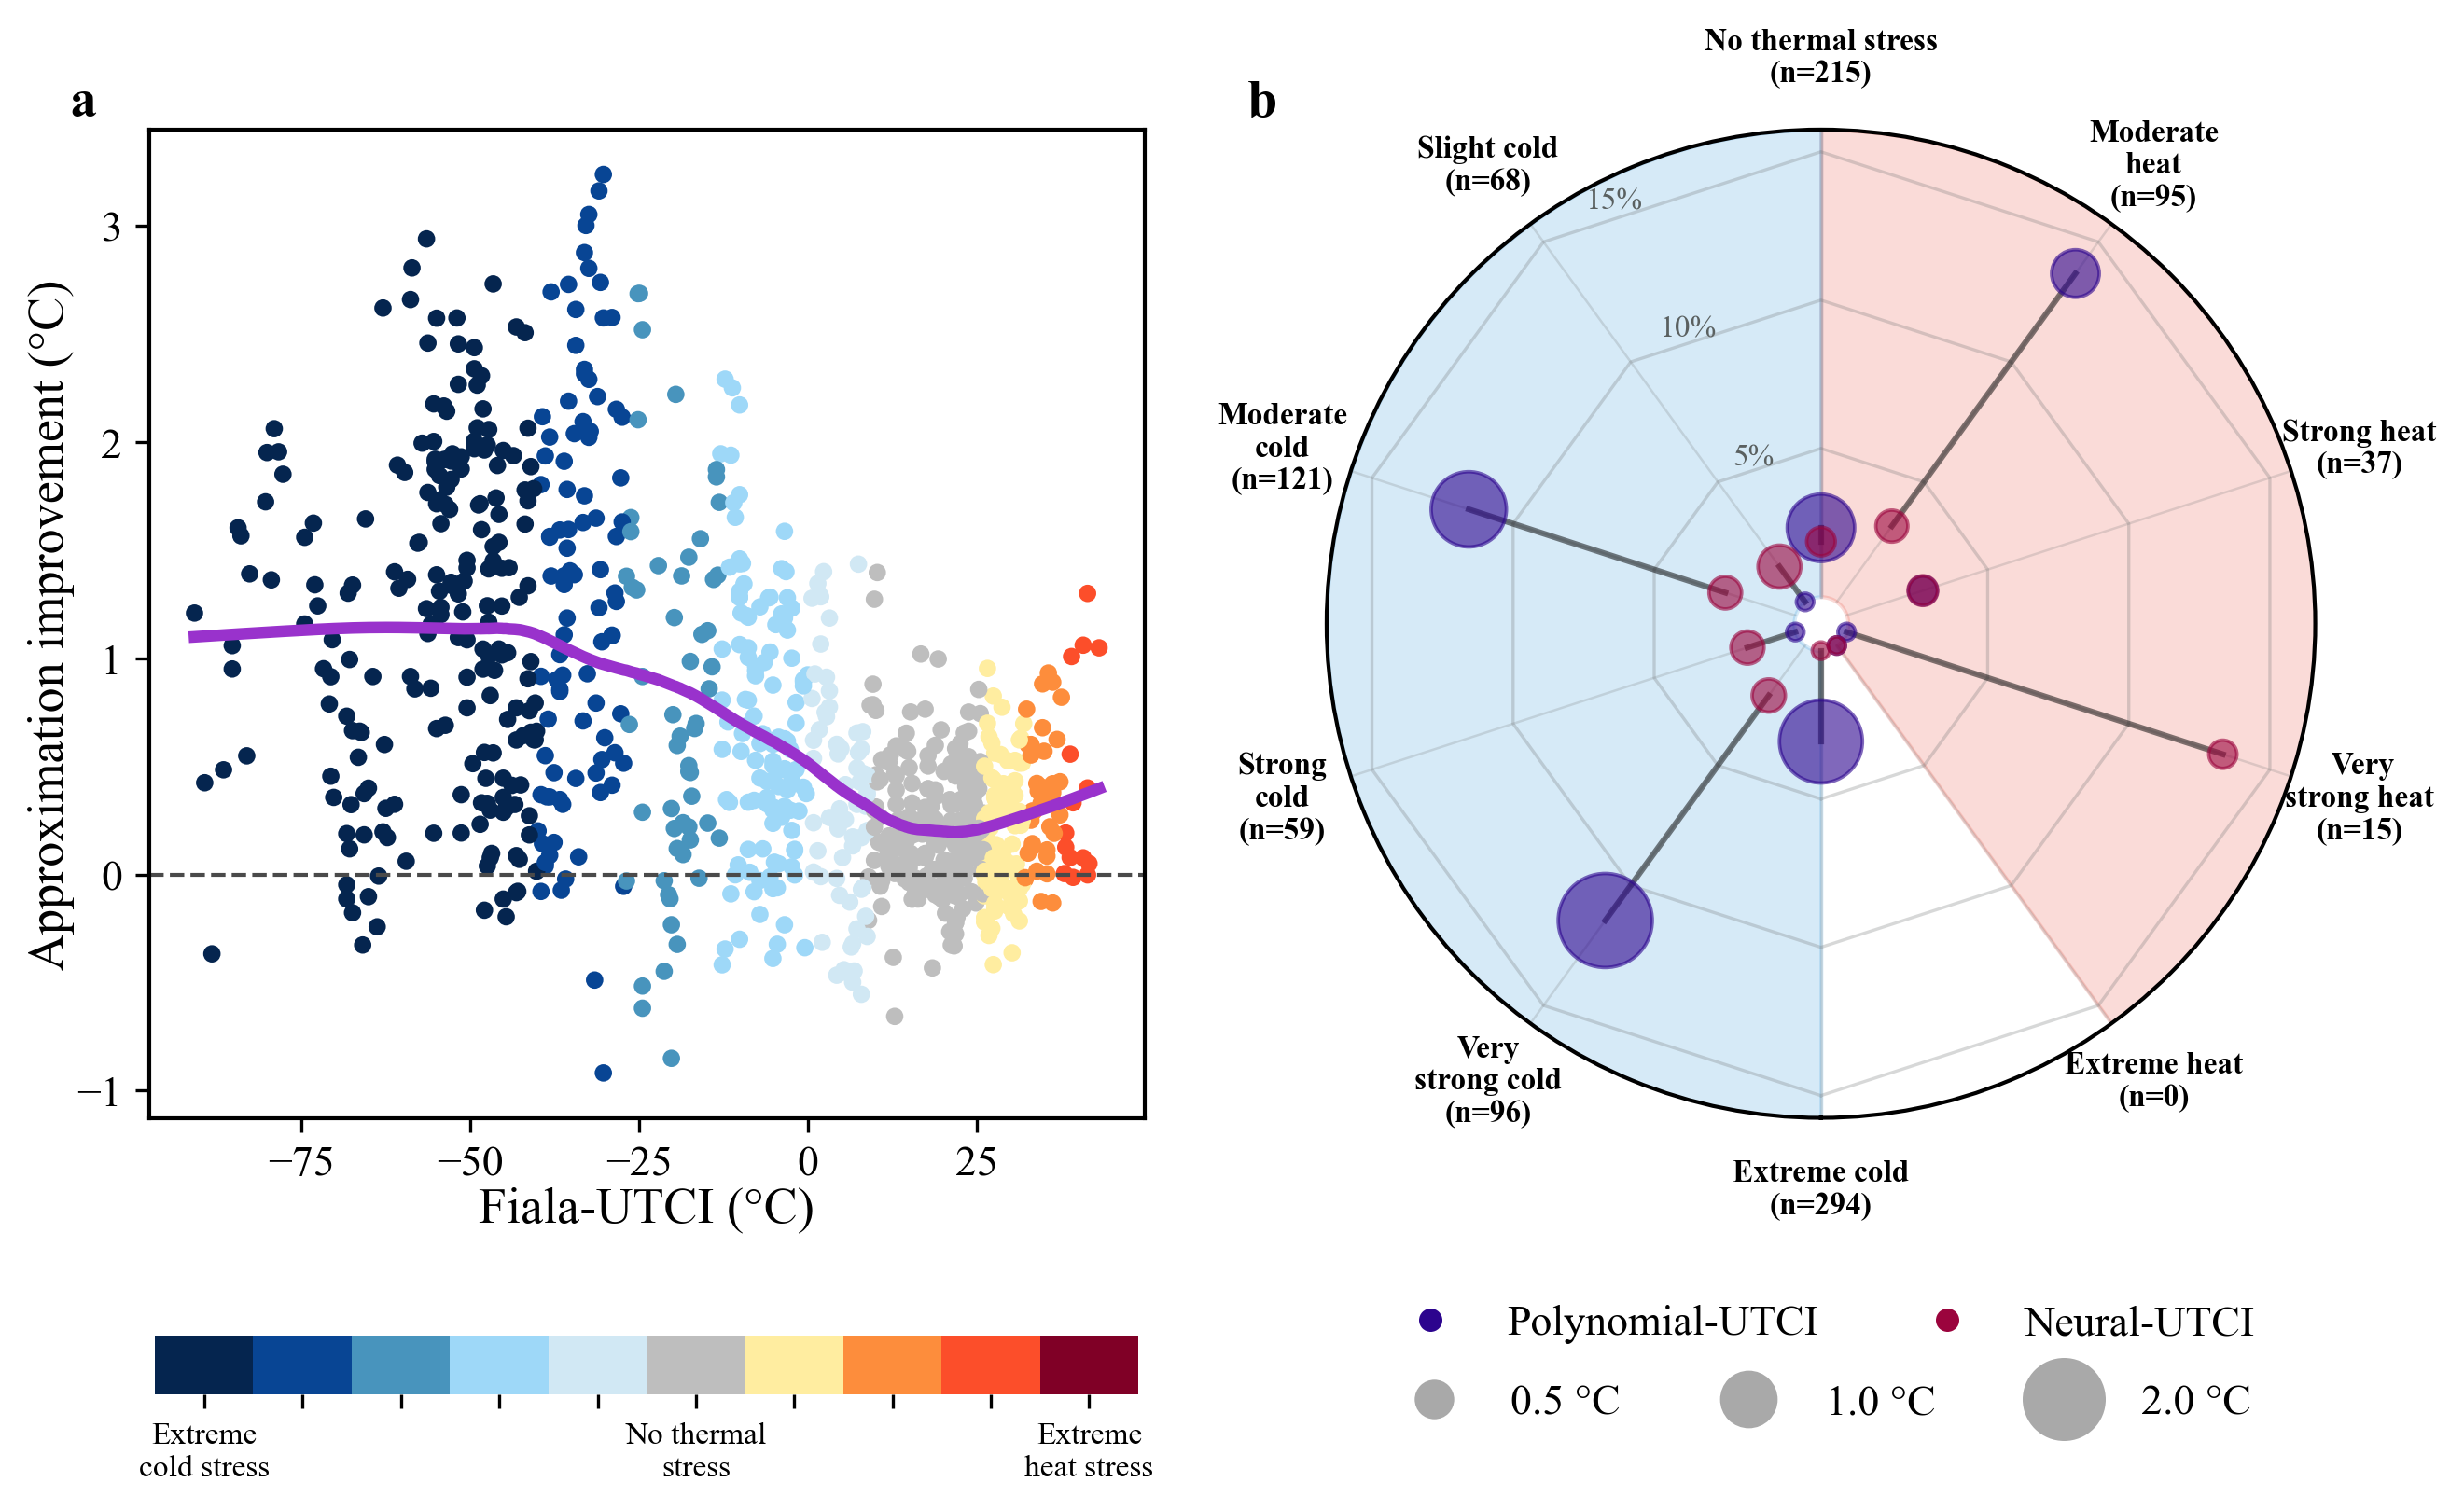

In [227]:
# --- Publication-quality rc settings (consistent + larger text) ---
plt.rcParams.update({
    'figure.dpi': 300,                    # screen DPI (saving overrides with fig.savefig)
    'savefig.dpi': 600,                   # high-res saves
    'font.family': 'serif',
    'font.serif': ['Times New Roman', 'Times', 'DejaVu Serif'],
    'font.size': 12,                      # base font size (controls many defaults)
    'axes.titlesize': 13,
    'axes.labelsize': 12,
    'axes.linewidth': 1.0,
    'xtick.labelsize': 11,
    'ytick.labelsize': 11,
    'legend.fontsize': 11,
    'legend.frameon': False,
    'lines.linewidth': 1.5,
    'lines.markersize': 6,
    'axes.grid': False,
    'pdf.fonttype': 42,  # embed fonts as Truetype in PDF (better portability)
    'ps.fonttype': 42,
})

# --- Create 2x2 subplot figure (arranged as in your design) ---
fig = plt.figure(figsize=(10, 10))  # reasonable manuscript size (inches)
gs = fig.add_gridspec(2, 2, hspace=0.18, wspace=0.18)

# Scatter plots occupy the two top panels
ax_poly = fig.add_subplot(gs[0, 0])  # Polynomial plot
ax_a = fig.add_subplot(gs[0, 1], projection='polar')  # Polar chart (replaces ax_nn) 

#################################################################
#### ========== Prepare the data ========== ####
#################################################################

# --- visual parameters ---
n_bins = 8
point_size = 50                 
outline_linewidth = 0.9
outline_color = '0.04'
va_outline_threshold = 17.0
band_alpha = 0.35
band_color = '#EDEDED'

# --- prepare bins, cmap and norm using the full va range (no filtering) ---
va_vals = test_analysis['va'].dropna()
bins = np.linspace(va_vals.min(), va_vals.max(), n_bins + 1)

# flipped colormap
cmap = plt.get_cmap('YlGnBu_r', n_bins)
norm = mcolors.BoundaryNorm(bins, ncolors=cmap.N, clip=True)

# tick labels
tick_positions = bins
tick_labels = [f"{b:.1f}" for b in bins]

# --- compute NN error band (global) ---
nn_max = test_analysis['nn_error'].max()
nn_min = test_analysis['nn_error'].min()
nn_range = nn_max - nn_min

# --- scatter kwargs used twice ---
scatter_kwargs = dict(
    c=test_analysis['va'],
    cmap=cmap,
    norm=norm,
    s=point_size,
    alpha=0.95,
    linewidths=0.4,
    edgecolors='none',
    marker='o',
    rasterized=True   # rasterize dense scatter when saving vector formats (keeps PDF size reasonable)
)

#################################################################
#### ========== catagory model improvement (TOP LEFT) ========== ####
#################################################################

# --- Data arrays for the LOWESS panel (filter va < 17 as you requested) ---
va_filter = test_analysis['va'] < 17
x = test_analysis.loc[va_filter, 'UTCI'].to_numpy()
y = test_analysis.loc[va_filter, 'abs_error_diff'].to_numpy()
cats = test_analysis.loc[va_filter, 'utci_category']

# --- Category → color mapping (fallback color if unknown) ---
color_map = {
    'Extreme heat stress': '#800026',
    'Very strong heat stress': '#FC4E2A', #'#BD0026',
    'Strong heat stress': '#FD8D3C', #'#FC4E2A',
    'Moderate heat stress': '#FFEDA0', #'#FD8D3C',
    'No thermal stress':  "#BEBEBE",#'#FFEDA0',
    'Slight cold stress': "#D1E8F4",
    'Moderate cold stress': "#9ED8F8",
    'Strong cold stress': "#4894BD",
    'Very strong cold stress': '#084594',
    'Extreme cold stress': "#05254F"
}
# Map categories to colors (pandas Series -> list)
point_colors = cats.map(color_map).tolist()


# --- Scatter plot of abs_error_diff vs UTCI on ax_poly ---
# Use a somewhat smaller point size for the panel unless you want the large manuscript size.
panel_point_size = 40

# Safety: if no data, annotate
if x.size == 0 or y.size == 0:
    ax_poly.text(0.5, 0.5, "No data (va < 17) available", ha='center', va='center')
    ax_poly.set_xlabel('Fiala-UTCI (°C)', fontsize=13)
    ax_poly.set_ylabel('Approximation improvement (°C)', fontsize=13)
else:
    # Scatter points colored by utci_category
    ax_poly.scatter(
        x, y,
        c=point_colors,
        alpha=1,
        s=20,
        linewidths=0.4,
        edgecolors='none',
        marker='o',
        rasterized=True,
        zorder=2
    )

    # --- LOWESS smoothing (guarded) ---
    frac = 0.4   # smoothing span (smaller -> less smooth)
    lowess_res = lowess(y, x, frac=frac, return_sorted=True)
    x_lowess = lowess_res[:, 0]
    y_lowess = lowess_res[:, 1]

    ax_poly.plot(
        x_lowess, y_lowess,
        color= 'darkorchid',#"#4C4A4A", #"#33B364",
        linewidth=3.0,
        label=f'LOWESS (frac={frac})',
        zorder=4
    )

        

    # Horizontal reference line at zero: positive values mean NN is better (|poly|-|nn| > 0),
    # negative values mean polynomial is better (|poly|-|nn| < 0)
    ax_poly.axhline(0, color='#4A4A4A', linestyle='--', linewidth=1) 

    # Labels and formatting
    ax_poly.set_xlabel('Fiala-UTCI (°C)', fontsize=13)
    ax_poly.set_ylabel('Approximation improvement (°C)', fontsize=13)

# Short text labels to show under each colour block (customise if you want)
# e.g., abbreviations or full names; must be same length/order as category_order
color_labels = [
    "Extreme\ncold stress", " ", " ", " ", " ",
    "No thermal\nstress", " ", " ", " ", "Extreme\nheat stress"
]

# colours for the legend in the same order
legend_colors = [color_map[cat] for cat in category_order]

# create a tiny inset axes under ax_poly to hold the discrete colourbar
# bbox_to_anchor and loc chosen so block sits below the axis; adjust bbox_to_anchor[1] (vertical offset) if needed
ax_cbar = inset_axes(
    ax_poly,
    width="130%",     # width of the block relative to ax_poly
    height="50%",     # height relative to ax_poly; tweak to make block taller/thinner
    loc='lower center',
    bbox_to_anchor=(0.12, -0.28, 0.76, 0.12),  # (x0, y0, width, height) in ax_poly fraction coords
    bbox_transform=ax_poly.transAxes,
    borderpad=0
)

# Build an image where each column is one colour (1 x N x 3)
Ncol = len(legend_colors)
img = np.zeros((1, Ncol, 3))
for i, hexc in enumerate(legend_colors):
    img[0, i, :] = to_rgb(hexc)

# show the colours as an image with each colour a vertical slice
ax_cbar.imshow(img, aspect='auto', extent=(0, Ncol, 0, 1))

# ticks: place a tick at each segment center and label with the short label + counts
ax_cbar.set_xticks(np.arange(0.5, Ncol + 0.5, 1.0))
ax_cbar.set_xticklabels([f"{color_labels[i]}" for i in range(Ncol)],
                        fontsize=8, rotation=0, ha='center', va='top')

# clean up the inset axes (no y-axis, no spines)
ax_cbar.set_yticks([])
for spine in ax_cbar.spines.values():
    spine.set_visible(False)

# make sure the inset doesn't capture x-grid/labels from main plot
ax_cbar.set_xlim(0, Ncol)
ax_cbar.set_ylim(0, 1)


#################################################################
#### ========== Polar plot (TOP RIGHT) ==========#####
#################################################################
# ---------------------------
# PANEL B (right, smaller-looking content inside same axes): RADIAL POLAR PLOT
# ---------------------------

# polar geometry
N = len(categories)
angles = np.linspace(0, 2 * np.pi, N, endpoint=False)
max_percentage = max(max(poly_percentages), max(nn_percentages), 15)

# ---- Shrink factor: 1.0 = full size (original behaviour); <1 makes the content smaller/centered ----
shrink_factor = 0.55

# compute the plotted radial positions (shrunk)
poly_radii = [p * shrink_factor for p in poly_percentages]
nn_radii = [p * shrink_factor for p in nn_percentages]

# draw rings and spokes (rings are drawn at shrunk positions for visual consistency)
percentage_rings = [5, 10, 15, 20, 25, 30]
ring_positions = [r * shrink_factor for r in percentage_rings if r <= max_percentage]

for rpos in ring_positions:
    ax_a.plot(np.append(angles, angles[0]), [rpos] * (N + 1), '-', color='#727676', linewidth=0.8, alpha=0.28)

for angle in angles:
    ax_a.plot([angle, angle], [0, max_percentage * shrink_factor * 1.05], color="#727676", linewidth=0.6, alpha=0.22)

# shaded regions for heat/cold context (use shrunk radial extent)
no_stress_index = None
extreme_heat_index = None
extreme_cold_index = None
for i, cat in enumerate(categories):
    if cat.lower() == 'no thermal stress':
        no_stress_index = i
    if cat == 'Extreme heat stress':
        extreme_heat_index = i
    if cat == 'Extreme cold stress':
        extreme_cold_index = i

if (no_stress_index is not None) and (extreme_heat_index is not None) and extreme_heat_index > no_stress_index:
    heat_angles = np.linspace(angles[no_stress_index], angles[extreme_heat_index], 120)
    ax_a.fill_between(heat_angles, 0, max_percentage * shrink_factor * 1.05, color='#E74C3C', alpha=0.2, zorder=1)
if (no_stress_index is not None) and (extreme_cold_index is not None) and extreme_cold_index < no_stress_index:
    cold_angles = np.linspace(angles[extreme_cold_index], angles[no_stress_index], 120)
    ax_a.fill_between(cold_angles, 0, max_percentage * shrink_factor * 1.05, color='#3498DB', alpha=0.2, zorder=1)

# marker sizes scaled by mean error magnitude; apply an additional visual shrink (so sizes match the smaller plot)
size_scale_factor = 250
visual_shrink = 1
poly_sizes = [max(20, abs(m) * size_scale_factor * visual_shrink) for m in poly_mean_errors]
nn_sizes = [max(20, abs(m) * size_scale_factor * visual_shrink) for m in nn_mean_errors]

# scatter: polynomial mismatches (green) and NN mismatches (magenta/red)
ax_a.scatter(angles, nn_radii, s=nn_sizes,
             c='#9B043D', alpha=0.6, linewidth=0.9, #edgecolors='darkgray',
             label=f'Neural Network (n={int(nn_mismatch.sum())})', zorder=7, rasterized=True)

ax_a.scatter(angles, poly_radii, s=poly_sizes,
             c='#2C048E', alpha=0.6, linewidth=0.9, #edgecolors='darkgray',
             label=f'Polynomial (n={int(poly_mismatch.sum())})', zorder=6, rasterized=True)




# connect the two model points within each category
for i, angle in enumerate(angles):
    ax_a.plot(
        [angle, angle],
        [poly_radii[i], nn_radii[i]],
        color='black',
        linewidth=1.5,
        alpha=0.5,
        zorder=5
    )

# formatting tuned for visually smaller polar content
ax_a.set_ylim(-0.5, max_percentage * shrink_factor * 1.05)        # keep axes slot same, but max radial value shrunk
ax_a.set_theta_offset(3 * np.pi / 2)
ax_a.set_theta_direction(-1)
ax_a.set_xticks(angles)

# keep numeric tick labels showing the real percentages, but place them at the shrunk positions
ax_a.set_yticks(ring_positions)
ax_a.set_rlabel_position(150)
ax_a.set_yticklabels([f'{r}%' for r in percentage_rings if r <= max_percentage], size=8, color="#5a6060")


custom_xtick_labels = [
    "Extreme cold",    # Extreme cold stress
    f"Very\nstrong cold",   # Very strong cold stress
    f"Strong\ncold",    # Strong cold stress
    f"Moderate\ncold",    # Moderate cold stress
    "Slight cold",   # Slight cold stress
    "No thermal stress",    # No thermal stress
    f"Moderate\nheat",    # Moderate heat stress
    "Strong heat",    # Strong heat stress
    f" Very\nstrong heat",   # Very strong heat stress
    "Extreme heat"     # Extreme heat stress
]


ax_a.set_xticklabels(
    [f"{custom_xtick_labels[i]}\n(n={totals[i]})" for i in range(len(categories))],
    size=8,
    weight='bold'
)


# shorten/stack xtick labels slightly to fit
ax_a.tick_params(axis='x', pad=8)
ax_a.grid(False)


#LEGENDS: create custom legend handles for colour and size
combined_means = np.array([v for v in poly_mean_errors + nn_mean_errors if v > 0])
# if combined_means.size == 0:
#     rep_errors = np.array([0.5, 1.0, 2.0])
# else:
#     rep_errors = np.percentile(combined_means, [25, 50, 75])

rep_errors = np.array([0.5, 1.0, 2.0])

size_handles = []
size_labels = []

for err in rep_errors:
    s = max(20, err * size_scale_factor * visual_shrink)
    size_handles.append(Line2D([0], [0], marker='o', color='w', markerfacecolor='darkgray',
                               markersize=np.sqrt(s), linestyle='None'))
    size_labels.append(f'{err:.1f} °C')

# Colour handles (mismatch types)
colour_handles = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor="#2C048E", markersize=7, label='Polynomial-UTCI'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#9B043D', markersize=7, label='Neural-UTCI')
]
# ax_a.legend(loc='upper left', bbox_to_anchor=(0.98, 1.12), frameon=False, fontsize=9)
# Combine colour and size legends into one below the polar axis
# We create a two-row legend: first colours, then sizes. We anchor it under ax_a.
legend1 = ax_a.legend(handles=colour_handles, ncol=2, frameon=False,
                      bbox_to_anchor=(0.5, -0.15), loc='upper center', title=None)

# then add the size legend below it
ax_a.legend(handles=size_handles, labels=size_labels, ncol=len(size_handles), frameon=False,
            bbox_to_anchor=(0.5, -0.23), loc='upper center')

# add the colour legend second
ax_a.add_artist(legend1)



# ========== PANEL LABELS ==========
panel_labels = ['a', 'b']
for idx, ax in enumerate([ax_poly, ax_a]):
    ax.text(-0.08, 1.05, panel_labels[idx], transform=ax.transAxes,
            fontsize=14, fontweight='bold', va='top', ha='left')



# Tidy layout for manuscript
plt.tight_layout(rect=[0, 0, 0.92, 1.0])  # leave room on right for colorbar / kde

# # --- SAVE FIGURE FOR MANUSCRIPT ---
fig.savefig("C:\\Users\\nerc-user\\OneDrive - Nexus365\\UTCI_NN\\Main\\figures\\main_text\\final\\fig_2_miscatagorisation.png", dpi=600, bbox_inches="tight", pad_inches=0.01)

plt.show()
